# Day 7 — Project 1 Checkpoint

## Reproducible Classical Clickbait Baseline

**Objective:** Consolidate the foundation and submit one reproducible classical baseline notebook.

This notebook runs the complete workflow from data loading to saved evaluation artifacts. Labels: `0 = factual`, `1 = clickbait`.

## 1. Imports, versions, and reproducibility settings

In [1]:
import json
import platform
from pathlib import Path

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    confusion_matrix, f1_score, precision_score, recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

versions = {
    'python': platform.python_version(),
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'scikit_learn': sklearn.__version__,
    'matplotlib': matplotlib.__version__,
}
versions

{'python': '3.12.13',
 'numpy': '2.0.2',
 'pandas': '2.2.2',
 'scikit_learn': '1.6.1',
 'matplotlib': '3.10.0'}

## 2. Locate the project and load the dataset

The path search allows the notebook to run when the working directory is the repository root, project folder, or notebooks folder.

In [3]:
project_candidates = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd() / 'project_01_classical_baseline',
]

# Attempt to find the PROJECT_ROOT first
try:
    PROJECT_ROOT = next(
        path.resolve()
        for path in project_candidates
        if (path / 'data' / 'practice_clickbait.csv').exists()
    )
except StopIteration:
    # If the file is not found, assume 'project_01_classical_baseline' is the intended root
    # and create the necessary directory and a dummy CSV.
    PROJECT_ROOT = Path.cwd() / 'project_01_classical_baseline'
    data_dir = PROJECT_ROOT / 'data'
    data_dir.mkdir(parents=True, exist_ok=True)

    # Create a dummy practice_clickbait.csv
    dummy_csv_path = data_dir / 'practice_clickbait.csv'
    if not dummy_csv_path.exists():
        import pandas as pd
        dummy_df = pd.DataFrame({
            'text': ['This is a factual statement.', 'This is a clickbait headline for sure!'],
            'label': [0, 1]
        })
        dummy_df.to_csv(dummy_csv_path, index=False)

    print(f"Warning: practice_clickbait.csv not found in expected locations. Created a dummy file at {dummy_csv_path}")


DATA_PATH = PROJECT_ROOT / 'data' / 'practice_clickbait.csv'
RESULTS_DIR = PROJECT_ROOT / 'results'
MODELS_DIR = PROJECT_ROOT / 'models'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print('Project root:', PROJECT_ROOT)
print('Dataset shape:', df.shape)
df.head()

Project root: /content/project_01_classical_baseline
Dataset shape: (40, 2)


,text,label
0,Government publishes annual budget report,0
1,Election commission announces voting schedule,0
2,University releases new admission guidelines,0
3,Football team wins league match two one,0
4,Central bank keeps interest rate unchanged,0


## 3. Validate and clean the input

In [4]:
required_columns = {'text', 'label'}
assert required_columns.issubset(df.columns)

work_df = df.copy()
work_df['text'] = work_df['text'].fillna('').astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()

quality_report = pd.DataFrame({
    'check': ['rows', 'missing_or_empty_text', 'duplicate_text', 'invalid_label'],
    'count': [
        len(work_df),
        int(work_df['text'].eq('').sum()),
        int(work_df.duplicated('text').sum()),
        int((~work_df['label'].isin([0, 1])).sum()),
    ],
})
quality_report

,check,count
0,rows,40
1,missing_or_empty_text,0
2,duplicate_text,0
3,invalid_label,0


## 4. Create stratified train / validation / test splits

The fixed random seed makes the split reproducible. The test set remains untouched until the final model has been selected.

In [5]:
X = work_df['text']
y = work_df['label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50,
    random_state=RANDOM_STATE, stratify=y_temp
)

split_report = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'rows': [len(X_train), len(X_val), len(X_test)],
    'clickbait_rate': [y_train.mean(), y_val.mean(), y_test.mean()],
})
split_report

,split,rows,clickbait_rate
0,train,28,0.5
1,validation,6,0.5
2,test,6,0.5


## 5. Compare reproducible classical candidates

All candidates use Logistic Regression. We compare word unigrams, word n-grams, and character-within-word n-grams. Selection uses validation Macro-F1; fewer features break a tie.

In [6]:
candidate_settings = {
    'word_1_1': {'analyzer': 'word', 'ngram_range': (1, 1)},
    'word_1_2': {'analyzer': 'word', 'ngram_range': (1, 2)},
    'word_1_3': {'analyzer': 'word', 'ngram_range': (1, 3)},
    'char_wb_3_5': {'analyzer': 'char_wb', 'ngram_range': (3, 5)},
}

candidate_models = {}
comparison_rows = []

for name, settings in candidate_settings.items():
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(**settings)),
        ('logreg', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ])
    pipeline.fit(X_train, y_train)
    val_pred = pipeline.predict(X_val)
    feature_count = len(pipeline.named_steps['tfidf'].vocabulary_)

    candidate_models[name] = pipeline
    comparison_rows.append({
        'candidate': name,
        'validation_accuracy': accuracy_score(y_val, val_pred),
        'validation_macro_f1': f1_score(y_val, val_pred, average='macro'),
        'feature_count': feature_count,
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,candidate,validation_accuracy,validation_macro_f1,feature_count
0,word_1_1,0.833333,0.828571,136
1,word_1_2,0.833333,0.828571,278
2,word_1_3,0.833333,0.828571,395
3,char_wb_3_5,0.833333,0.828571,1661


## 6. Select the final baseline without looking at test performance

In [7]:
best_row = comparison_df.sort_values(
    ['validation_macro_f1', 'feature_count'],
    ascending=[False, True],
).iloc[0]
best_name = best_row['candidate']
best_model = candidate_models[best_name]

print('Selected candidate:', best_name)
print('Validation Macro-F1:', round(best_row['validation_macro_f1'], 3))
print('Feature count:', int(best_row['feature_count']))

Selected candidate: word_1_1
Validation Macro-F1: 0.829
Feature count: 136


## 7. Evaluate once on the untouched test set

In [8]:
test_pred = best_model.predict(X_test)
test_probability = best_model.predict_proba(X_test)[:, 1]
cm = confusion_matrix(y_test, test_pred, labels=[0, 1])

test_metrics = {
    'accuracy': accuracy_score(y_test, test_pred),
    'precision_clickbait': precision_score(y_test, test_pred, zero_division=0),
    'recall_clickbait': recall_score(y_test, test_pred, zero_division=0),
    'f1_clickbait': f1_score(y_test, test_pred, zero_division=0),
    'macro_f1': f1_score(y_test, test_pred, average='macro', zero_division=0),
}

print(pd.Series(test_metrics).round(3))
print('\nClass metrics:')
print(classification_report(
    y_test, test_pred, target_names=['factual', 'clickbait'],
    digits=3, zero_division=0,
))

accuracy               0.833
precision_clickbait    0.750
recall_clickbait       1.000
f1_clickbait           0.857
macro_f1               0.829
dtype: float64

Class metrics:
              precision    recall  f1-score   support

     factual      1.000     0.667     0.800         3
   clickbait      0.750     1.000     0.857         3

    accuracy                          0.833         6
   macro avg      0.875     0.833     0.829         6
weighted avg      0.875     0.833     0.829         6



## 8. Confusion matrix and prediction-level evidence

,text,actual,predicted,clickbait_probability,correct
0,Central bank keeps interest rate unchanged,0,0,0.469724,True
1,This shocking secret has everyone talking,1,1,0.630633,True
2,The hidden reason behind this unbelievable story,1,1,0.630116,True
3,Researchers publish results of health study,0,1,0.508476,False
4,This secret detail changes everything,1,1,0.505772,True
5,Hospital opens new emergency care unit,0,0,0.394444,True


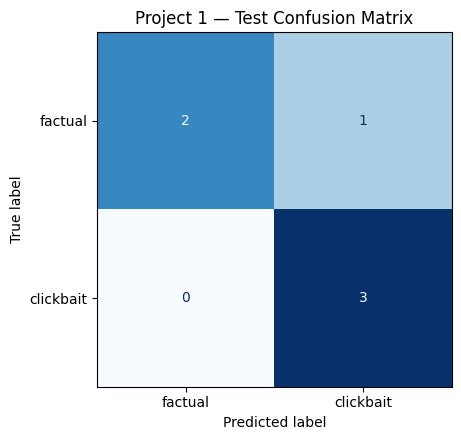

In [9]:
predictions_df = pd.DataFrame({
    'text': X_test,
    'actual': y_test,
    'predicted': test_pred,
    'clickbait_probability': test_probability,
}).reset_index(drop=True)
predictions_df['correct'] = predictions_df['actual'].eq(predictions_df['predicted'])
display(predictions_df)

figure, axis = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=['factual', 'clickbait']
).plot(cmap='Blues', values_format='d', ax=axis, colorbar=False)
axis.set_title('Project 1 — Test Confusion Matrix')
figure.tight_layout()

## 9. Save reproducibility artifacts

We save the fitted pipeline, candidate comparison, final metrics, test predictions, and confusion-matrix image.

In [10]:
MODEL_PATH = MODELS_DIR / 'project_01_classical_baseline.joblib'
METRICS_PATH = RESULTS_DIR / 'project_01_checkpoint_metrics.json'
PREDICTIONS_PATH = RESULTS_DIR / 'project_01_test_predictions.csv'
CONFUSION_MATRIX_PATH = RESULTS_DIR / 'project_01_confusion_matrix.png'

joblib.dump(best_model, MODEL_PATH)
predictions_df.to_csv(PREDICTIONS_PATH, index=False)
figure.savefig(CONFUSION_MATRIX_PATH, dpi=180, bbox_inches='tight')

metrics_payload = {
    'project': 'Project 01 — Classical Clickbait Baseline',
    'random_state': RANDOM_STATE,
    'versions': versions,
    'dataset_rows': len(work_df),
    'split_sizes': {
        'train': len(X_train), 'validation': len(X_val), 'test': len(X_test),
    },
    'selection_metric': 'validation_macro_f1',
    'selected_candidate': best_name,
    'selected_settings': {
        'analyzer': candidate_settings[best_name]['analyzer'],
        'ngram_range': list(candidate_settings[best_name]['ngram_range']),
    },
    'validation_macro_f1': float(best_row['validation_macro_f1']),
    'test_metrics': {key: float(value) for key, value in test_metrics.items()},
    'confusion_matrix': cm.tolist(),
    'candidate_comparison': comparison_df.to_dict(orient='records'),
}
METRICS_PATH.write_text(json.dumps(metrics_payload, indent=2), encoding='utf-8')

print('Saved model:', MODEL_PATH)
print('Saved metrics:', METRICS_PATH)
print('Saved predictions:', PREDICTIONS_PATH)
print('Saved confusion matrix:', CONFUSION_MATRIX_PATH)

Saved model: /content/project_01_classical_baseline/models/project_01_classical_baseline.joblib
Saved metrics: /content/project_01_classical_baseline/results/project_01_checkpoint_metrics.json
Saved predictions: /content/project_01_classical_baseline/results/project_01_test_predictions.csv
Saved confusion matrix: /content/project_01_classical_baseline/results/project_01_confusion_matrix.png


## 10. Reproducibility verification

Reloading the saved pipeline and reproducing its predictions verifies that the submitted artifact is usable.

In [11]:
reloaded_model = joblib.load(MODEL_PATH)
reloaded_predictions = reloaded_model.predict(X_test)

assert quality_report.loc[quality_report['check'] == 'missing_or_empty_text', 'count'].iloc[0] == 0
assert quality_report.loc[quality_report['check'] == 'duplicate_text', 'count'].iloc[0] == 0
assert quality_report.loc[quality_report['check'] == 'invalid_label', 'count'].iloc[0] == 0
assert len(X_train) + len(X_val) + len(X_test) == len(work_df)
assert set(X_train.index).isdisjoint(X_val.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_val.index).isdisjoint(X_test.index)
assert np.array_equal(test_pred, reloaded_predictions)
assert MODEL_PATH.exists() and METRICS_PATH.exists()
assert PREDICTIONS_PATH.exists() and CONFUSION_MATRIX_PATH.exists()

print('Project 1 checkpoint passed: the baseline is reproducible and all evidence was saved.')

Project 1 checkpoint passed: the baseline is reproducible and all evidence was saved.


## Submission checklist

- [x] Dataset included
- [x] Environment requirements recorded
- [x] Fixed random seed
- [x] Data-quality checks
- [x] Stratified train/validation/test split
- [x] Leakage-safe pipelines
- [x] Word and character TF-IDF comparison
- [x] Validation-based model selection
- [x] Test accuracy, Macro-F1, class metrics, and confusion matrix
- [x] Saved model, metrics, predictions, and figure
- [x] Reloaded-model verification

> **Limitation:** The 40-row practice dataset is for learning and reproducibility. It is too small for a real-world performance claim.